### Uwagi / plan

> PROBLEM 1: Mamy różne rodzaje plików 
> - continuous: wszystkie spektra takie same 
> - processed: tutaj mamy różne peaki
> W jaki sposób to jest uwzględniane w modelu, oraz jak to można wyodrębnić, żeby pomiędzy wieloma obrazami móc to zapisać



> OGÓLNY PLAN: 
> - chcemy zrobić model który WIELE zdjęc jest w stanie kompresować do TEJ SAMEJ *przestrzeni ukrytej*, w ten sposób móc tworzyć widma które zachowują konkretną informacje 
> - po trenowaniu z takiej sieci można by usunąć węzły które nie wprowadzają informacji (żeby przyspieszyć model) 
>


### DO CHAT'A

> Czym różnią się continuous i processed data, jak to się inaczej przechowuje jak to potem wpływa na czytanie takich danych, na korzystanie z takich danych, w jaki sposób można "upodobnić tą ceche" do pozostałych, jakie są jeszcze inne rodzaje spektra 

###

In [1]:
from pprint import pprint
import m2aia as m2
import numpy as np


import os
from pathlib import Path

# seting global dir
cwd=Path.cwd()
if cwd.name == "tutorials":
    # os.chdir(cwd.parent.parent) 
    os.chdir(cwd.parent) 
os.getcwd()

'/home/maxi7524/repositories/pym2aia_test'

### Data formats 

#### Processed data

All spectra (m/z vector) have his own dimension
- all spectra have different dimension 
- detector adjust to different samples

```shell
# parameter
'[IMS:1000031] processed': 'true',
```

#### Continuous

Alle spectra (m/z vector) have same resolution 
- All spectra have same dimension ()
- it takes less space, load faster

```shell
# parameter
'[IMS:1000031] processed': 'false',
```

### Shape of data

#### Profile

Data are saved in as contionus peaks (we can see peaks)

```shell
# parameter
 'm2aia.imzml.spectrum_type': 'profile spectrum',
```

#### Centroid 

We obtain only single bars 


> TODO prezentacja - tutaj najelpiej po prostu załadować dane i pokazac przykład w jaki sposób to działa. 

#### Warnings explanations:

```shell
WARNING: Processed profile spectrum is not fully supported! Check the ImzML file.
```

> Informations from above ...

In [ ]:
# data loading 
PATH_DATA = Path('data')
PATH_sim_data = PATH_DATA / 'simulation_data' / 'test_4_final.imzML'
print(PATH_sim_data.exists())
PATH_real_data = PATH_DATA / 'bladder_data' / 'mouse_bladder.imzML'
print(PATH_real_data.exists())

# load data - IMPORTANT (NEED TO PASS STR)
reader_real = m2.ImzMLReader(str(PATH_real_data))


!Sat Apr 18 10:11:16 2026 
2.916! WARNING: No pixel size found, set x and y spacing to 50 microns!
[4.701] Initialization of the Normalization images took: 1.7137 Average(1 runs):1.7137s
!7.423! WARNING: Processed profile spectrum is not fully supported! Check the ImzML file.
[8.120] [imzML]: data/bladder_data/mouse_bladder.imzML
	[pixel size (mm)]: 0.050000x0.050000x0.010000
	[image dimension]: 260x134x1
	[num spectra]: 34840
	[spec. type]: ProcessedProfile
	[mass range]: 400.259620 to 999.795899 with #1500 measurements


In [4]:
# meta data
print("Spectrum Type:", reader_real.GetSpectrumType())
print("Dimensions:", reader_real.GetShape())
print("Pixel Spacing:", reader_real.GetSpacing())
print("Pixels:", reader_real.GetNumberOfSpectra())
print("Off-Pixels:", np.abs(np.prod(reader_real.GetShape()) - reader_real.GetNumberOfSpectra()))
print("m/z Bins:", reader_real.GetXAxisDepth())

Spectrum Type: ProcessedProfile
Dimensions: [260 134   1]
Pixel Spacing: [0.05 0.05 0.01]
Pixels: 34840
Off-Pixels: 0
m/z Bins: 1500


In [5]:
reader_real.GetMetaData()

{'(original imzML value) [IMS:1000042] max count of pixels x': '260',
 '(original imzML value) [IMS:1000043] max count of pixels y': '134',
 '(original imzML value) max count of pixels z': '1',
 '[IMS:1000031] processed': 'true',
 '[IMS:1000042] max count of pixels x': '260',
 '[IMS:1000043] max count of pixels y': '134',
 '[IMS:1000046] pixel size x': '0.05',
 '[IMS:1000047] pixel size y': '0.05',
 '[IMS:1000053] absolute position offset x': '0',
 '[IMS:1000054] absolute position offset y': '0',
 '[IMS:1000080] universally unique identifier': '{C7822330-F1A8-4D11-AD30-504B30B33722}',
 '[IMS:1000091] ibd SHA-1': 'F8C24417B294BFA168D75A470BBB361009BC2671',
 '[IMS:1000101] intensityArray.external data': 'true',
 '[IMS:1000101] mzArray.external data': 'true',
 '[IMS:1000401] scansettings1.top down': 'true',
 '[IMS:1000413] scansettings1.flyback': 'true',
 '[IMS:1000480] scansettings1.horizontal line scan': 'true',
 '[IMS:1000491] scansettings1.linescan left right': 'true',
 '[MS:1000001] 

### Visualization of spectra

#### Profile

Here we obtain two different arrays for each pixels (`mz` / `intensities` $\equiv$ *pixels* / *m/z value at pixel*)

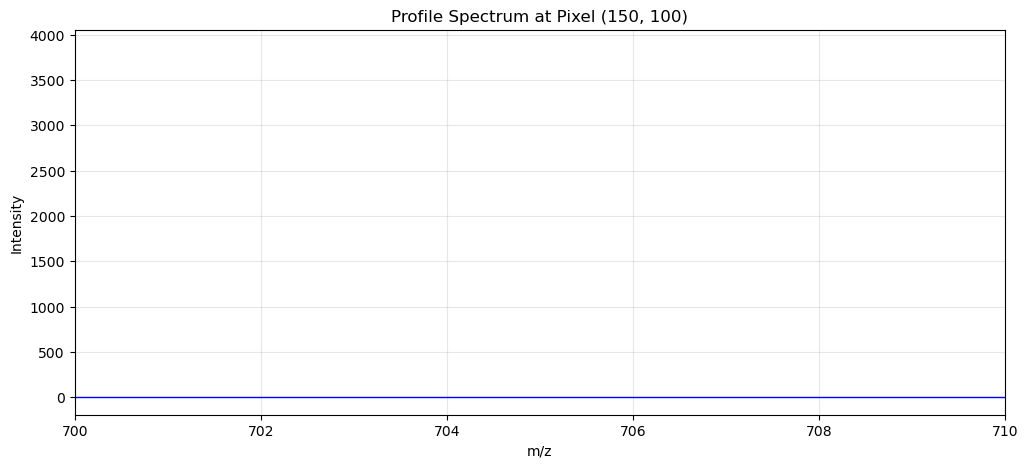

In [6]:
# plotting spectrum (profile data)

import matplotlib.pyplot as plt
import numpy as np

# Choose a pixel coordinate (x, y)
x_coord, y_coord = 150, 100 # roughly the middle of your 260x134 image
width = 260

# Calculate the linear index (M2aia uses 0-based linear indexing)
pixel_index = y_coord * width + x_coord

# Get data for this specific pixel
# Since it's 'Processed', we MUST get the X-axis for this specific index
# mzs = reader_real.GetXAxis()
# TODO - remark - here we have two different mzs / intensities for each pixel !!!!
mzs, intensities = reader_real.GetSpectrum(pixel_index)

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(mzs, intensities, linewidth=1, color='blue')
plt.title(f"Profile Spectrum at Pixel ({x_coord}, {y_coord})")
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.grid(True, alpha=0.3)

# Zooming in to see the 'Profile' shape (e.g., a 10 Da window)
plt.xlim(700, 710) 
plt.show()

### Data processing 

> TODO
- to trzeba bardzo dokøadnie przejrzec i stworzyc pipeline, ktory dla danego typu danych będzie robił odpowiendie procedury (będzie trzeba wszystko ustandaryzować żeby to skalowanie miało sens) 

#### All data

##### Deisotoping
- Here we group our results around certain spectrum of molecule and we minimize margin error from those molecules (we center our results to nearest possible values) 

##### Charge state deconvolution

in IMS-MS molecules can obtain many possible charges, as a result we obtain different m/z intensities values. To solve problem we need to solve equations of form:
$$ \mathrm{I}_{m, z_i} = \frac{M_m + z_i H_m}{z_i} $$
for different values of $z_i$

#### Profile

##### Binning and resampling 

We discretize the domain of our spectrum. 

##### Normalization 


#### Profile data

In [27]:
# 1. Smoothing (Gaussian is great for Orbitrap profile data)
reader_real.SetSmoothing("Gaussian", 2) # half-window size of 2

# 2. Baseline Correction (TopHat is very popular for MSI)
reader_real.SetBaselineCorrection("TopHat", 50) # hws of 50

# 3. Normalization (TIC - Total Ion Current - is the gold standard)
reader_real.SetNormalization("TIC")

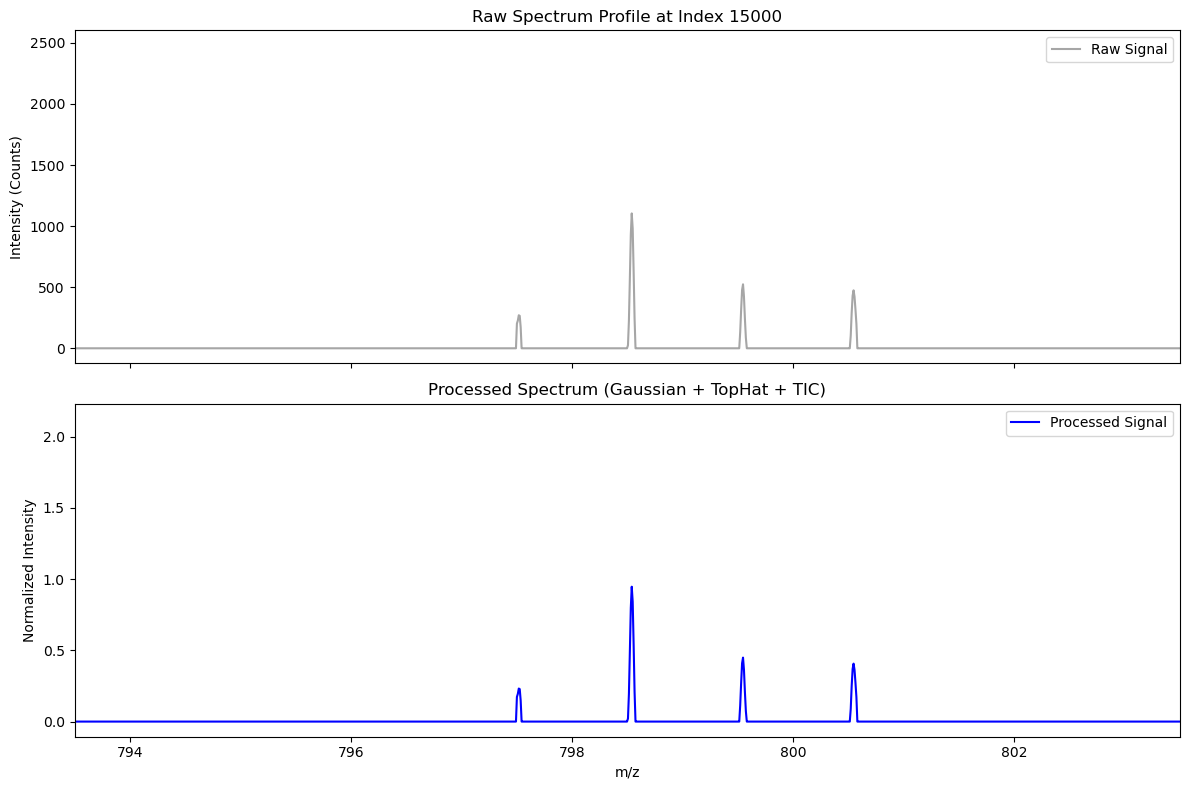

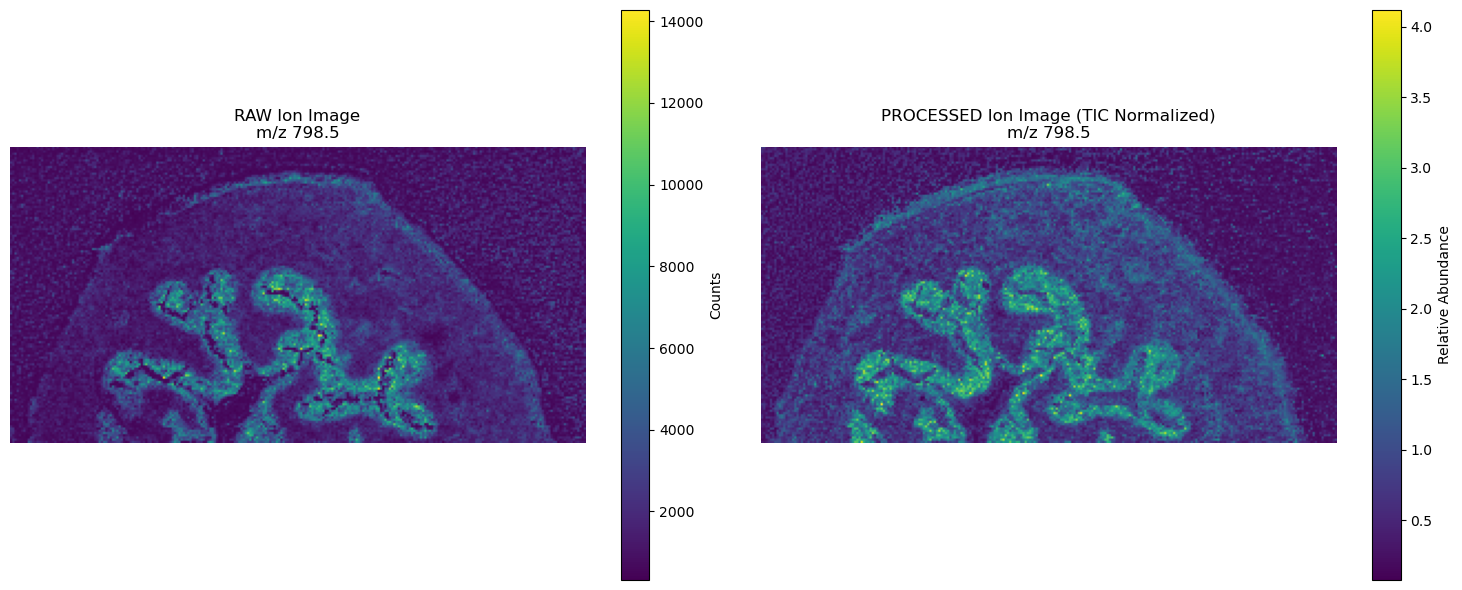

In [ ]:
import matplotlib.pyplot as plt
import m2aia as m2
import numpy as np

# --- CONFIGURATION ---
pixel_idx = 15000  # Example pixel index inside the tissue
target_mz = 798.5  # Target mass (e.g., a lipid)
tolerance = 50     # ppm
window_size = 5    # m/z window for zooming in the plot

# 1. GET CLEAN DATA (Processing Enabled)
# Applying filters using string identifiers to avoid AttributeError
reader_real.SetSmoothing("Gaussian", 2)
reader_real.SetBaselineCorrection("TopHat", 50)
reader_real.SetNormalization("TIC")

# In Processed mode, GetSpectrum returns [mzs, intensities]
clean_mzs, clean_intensities = reader_real.GetSpectrum(pixel_idx)
clean_img = reader_real.GetArray(target_mz, tolerance, np.float32, True)

# 2. GET RAW DATA (Processing Disabled)
# We reset the reader to its default state
reader_real.SetNormalization("None")
reader_real.SetBaselineCorrection("None", 0)
reader_real.SetSmoothing("None", 0)

raw_mzs, raw_intensities = reader_real.GetSpectrum(pixel_idx)
raw_img = reader_real.GetArray(target_mz, tolerance, np.float32, True)

# --- VISUALIZATION 1: SPECTRUM COMPARISON ---
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top Plot: Raw Data
ax[0].plot(raw_mzs, raw_intensities, color='gray', alpha=0.7, label='Raw Signal')
ax[0].set_title(f"Raw Spectrum Profile at Index {pixel_idx}")
ax[0].set_ylabel("Intensity (Counts)")
ax[0].legend()

# Bottom Plot: Processed Data
ax[1].plot(clean_mzs, clean_intensities, color='blue', label='Processed Signal')
ax[1].set_title("Processed Spectrum (Gaussian + TopHat + TIC)")
ax[1].set_ylabel("Normalized Intensity")
ax[1].legend()

plt.xlim(target_mz - window_size, target_mz + window_size)
plt.xlabel("m/z")
plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: ION IMAGE COMPARISON ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Raw Ion Image
im1 = ax1.imshow(raw_img, cmap='viridis')
ax1.set_title(f"RAW Ion Image\nm/z {target_mz}")
ax1.axis('off')
fig.colorbar(im1, ax=ax1, label='Counts')

# Clean Ion Image
im2 = ax2.imshow(clean_img, cmap='viridis')
ax2.set_title(f"PROCESSED Ion Image (TIC Normalized)\nm/z {target_mz}")
ax2.axis('off')
fig.colorbar(im2, ax=ax2, label='Relative Abundance')

plt.tight_layout()
plt.show()

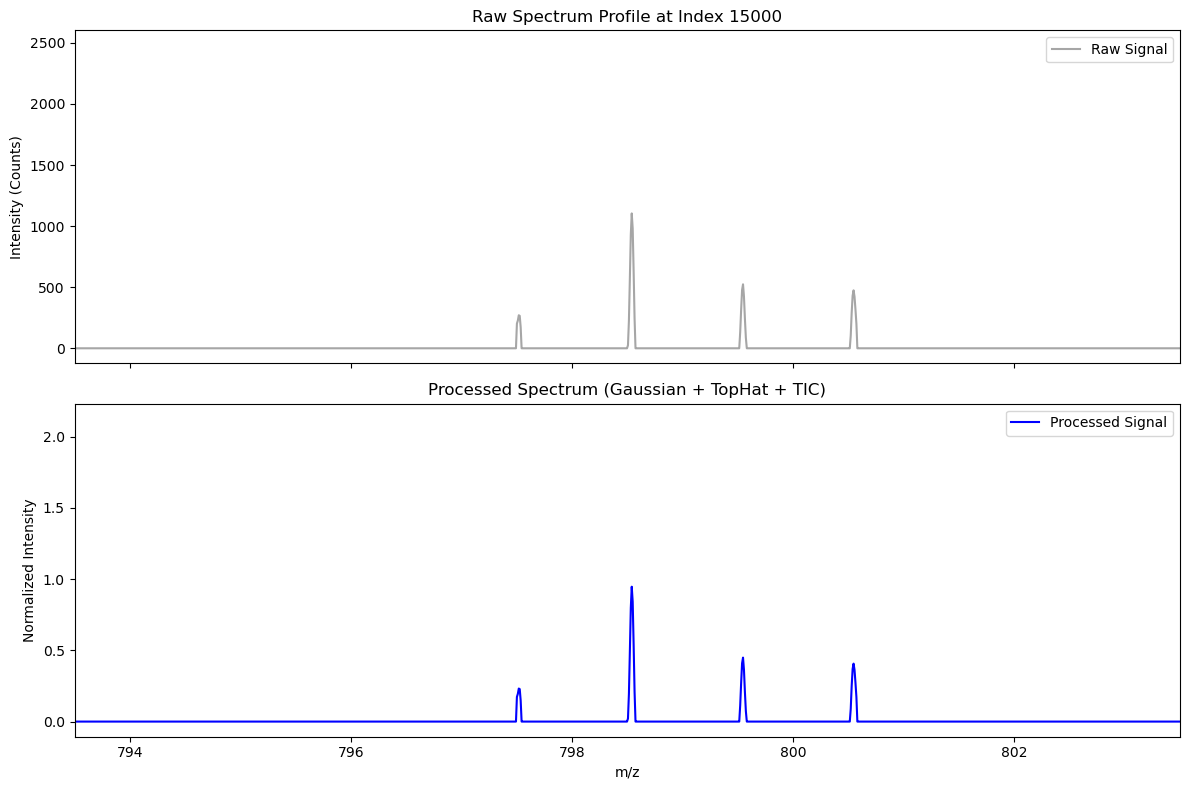

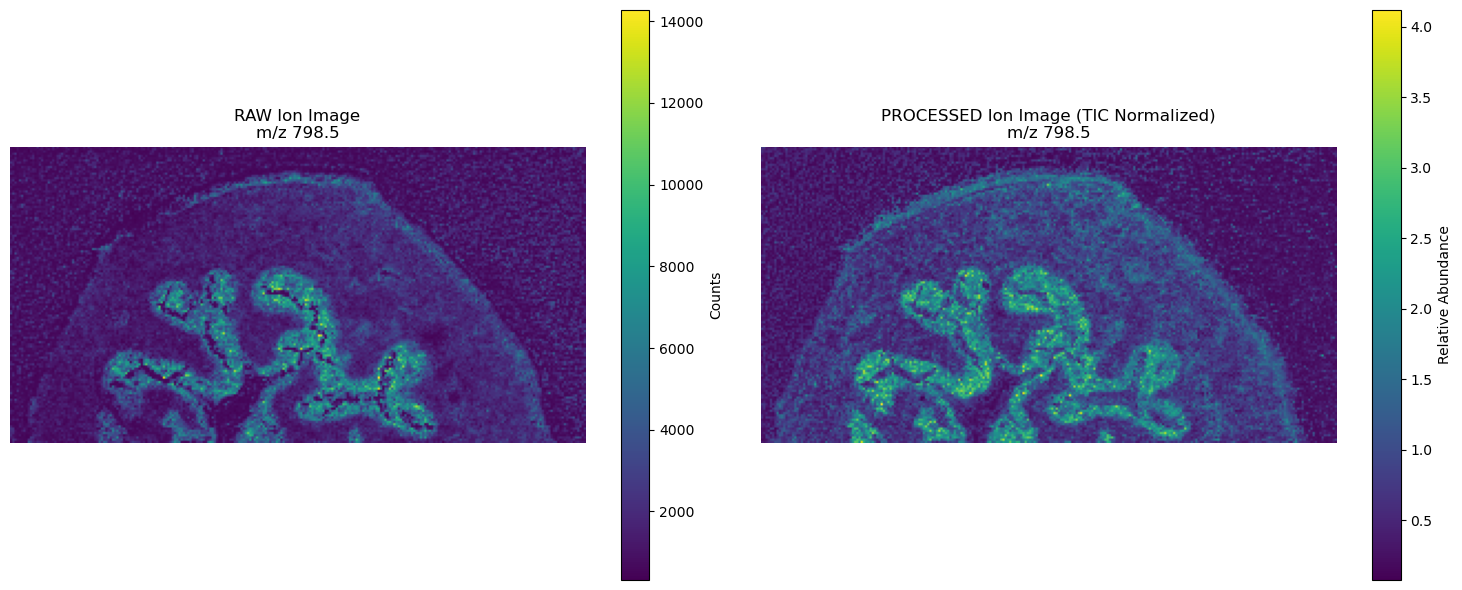

In [8]:
import matplotlib.pyplot as plt
import m2aia as m2
import numpy as np

# --- CONFIGURATION ---
pixel_idx = 15000  # Example pixel index inside the tissue
target_mz = 798.5  # Target mass (e.g., a lipid)
tolerance = 50     # ppm
window_size = 5    # m/z window for zooming in the plot

# 1. GET CLEAN DATA (Processing Enabled)
# Applying filters using string identifiers to avoid AttributeError
reader_real.SetSmoothing("Gaussian", 100)
reader_real.SetBaselineCorrection("TopHat", 50)
reader_real.SetNormalization("TIC")

# In Processed mode, GetSpectrum returns [mzs, intensities]
clean_mzs, clean_intensities = reader_real.GetSpectrum(pixel_idx)
clean_img = reader_real.GetArray(target_mz, tolerance, np.float32, True)

# 2. GET RAW DATA (Processing Disabled50
# We reset the reader to its default state
reader_real.SetNormalization("None")
reader_real.SetBaselineCorrection("None", 0)
reader_real.SetSmoothing("None", 0)

raw_mzs, raw_intensities = reader_real.GetSpectrum(pixel_idx)
raw_img = reader_real.GetArray(target_mz, tolerance, np.float32, True)

# --- VISUALIZATION 1: SPECTRUM COMPARISON ---
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top Plot: Raw Data
ax[0].plot(raw_mzs, raw_intensities, color='gray', alpha=0.7, label='Raw Signal')
ax[0].set_title(f"Raw Spectrum Profile at Index {pixel_idx}")
ax[0].set_ylabel("Intensity (Counts)")
ax[0].legend()

# Bottom Plot: Processed Data
ax[1].plot(clean_mzs, clean_intensities, color='blue', label='Processed Signal')
ax[1].set_title("Processed Spectrum (Gaussian + TopHat + TIC)")
ax[1].set_ylabel("Normalized Intensity")
ax[1].legend()

plt.xlim(target_mz - window_size, target_mz + window_size)
plt.xlabel("m/z")
plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: ION IMAGE COMPARISON ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Raw Ion Image
im1 = ax1.imshow(raw_img, cmap='viridis')
ax1.set_title(f"RAW Ion Image\nm/z {target_mz}")
ax1.axis('off')
fig.colorbar(im1, ax=ax1, label='Counts')

# Clean Ion Image
im2 = ax2.imshow(clean_img, cmap='viridis')
ax2.set_title(f"PROCESSED Ion Image (TIC Normalized)\nm/z {target_mz}")
ax2.axis('off')
fig.colorbar(im2, ax=ax2, label='Relative Abundance')

plt.tight_layout()
plt.show()

Porównanie wszystkich metryk